# Config/imports

All experimental processing below uses the current live streams. `NUMBER_OF_LIVE_SAMPLES` is the single acquisition-size control; change it (for example to 100) before executing the notebook.

In [1]:
from pathlib import Path
import sys
import time
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "stream_server.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from stream_client import GyroStreamClient
from allan_variance import allan_deviation
from algorithms.fusion import compute_error_metrics
from algorithms.ekf import run_basic_ekf
from algorithms.imm import LinearGaussian1DIMM
from algorithms.association import pma_update

SAMPLE_RATE = 200.0
DT = 1.0 / SAMPLE_RATE
GYRO_IDS = list(range(1, 9))
GYRO_PORTS = list(range(5001, 5009))
BASELINE_PORT = 5009
NUMBER_OF_LIVE_SAMPLES = 1000
ALLAN_SOURCE = "imm_association"  # live_gyro1, basic_fusion, imm_association, or ekf
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"project={PROJECT_ROOT}; samples={NUMBER_OF_LIVE_SAMPLES}; allan_source={ALLAN_SOURCE}")


project=C:\Users\shara\Downloads\gyroscope_2 - Copy; samples=1000; allan_source=imm_association


# Offline reference

Offline files are checked for reproducibility only. They are not assigned to any experimental processing variable.

In [2]:
offline_reference = {}
for i in GYRO_IDS:
    path = PROJECT_ROOT / "data" / "organized" / f"gyro_{i}.csv"
    offline_reference[f"gyro{i}"] = {"path": str(path), "exists": path.exists(),
                                      "bytes": path.stat().st_size if path.exists() else 0}
base_path = PROJECT_ROOT / "data" / "baseline" / "baseline_gyro_readings.csv"
offline_reference["baseline"] = {"path": str(base_path), "exists": base_path.exists(),
                                  "bytes": base_path.stat().st_size if base_path.exists() else 0}
print(pd.DataFrame(offline_reference).T)


                                                       path exists   bytes
gyro1     C:\Users\shara\Downloads\gyroscope_2 - Copy\da...   True  869613
gyro2     C:\Users\shara\Downloads\gyroscope_2 - Copy\da...   True  872348
gyro3     C:\Users\shara\Downloads\gyroscope_2 - Copy\da...   True  868057
gyro4     C:\Users\shara\Downloads\gyroscope_2 - Copy\da...   True  874033
gyro5     C:\Users\shara\Downloads\gyroscope_2 - Copy\da...   True  863294
gyro6     C:\Users\shara\Downloads\gyroscope_2 - Copy\da...   True  858304
gyro7     C:\Users\shara\Downloads\gyroscope_2 - Copy\da...   True  864850
gyro8     C:\Users\shara\Downloads\gyroscope_2 - Copy\da...   True  860020
baseline  C:\Users\shara\Downloads\gyroscope_2 - Copy\da...   True  817262


# Connect 9 ports

A missing port is an error. There is no offline fallback.

In [3]:
live_clients = {}
try:
    for port in GYRO_PORTS + [BASELINE_PORT]:
        live_clients[port] = GyroStreamClient(host="127.0.0.1", port=port, timeout=5.0)
except Exception:
    for client in live_clients.values():
        client.close()
    raise
if len(live_clients) != 9:
    raise RuntimeError(f"Expected 9 live clients, got {len(live_clients)}")
print("Connected ports:", sorted(live_clients))


Connected ports: [5001, 5002, 5003, 5004, 5005, 5006, 5007, 5008, 5009]


# Live acquisition

Each connected stream is read concurrently so timestamps remain the timestamps delivered by the server.

{'gyro1': 1000, 'gyro2': 1000, 'gyro3': 1000, 'gyro4': 1000, 'gyro5': 1000, 'gyro6': 1000, 'gyro7': 1000, 'gyro8': 1000, 'baseline': 1000}


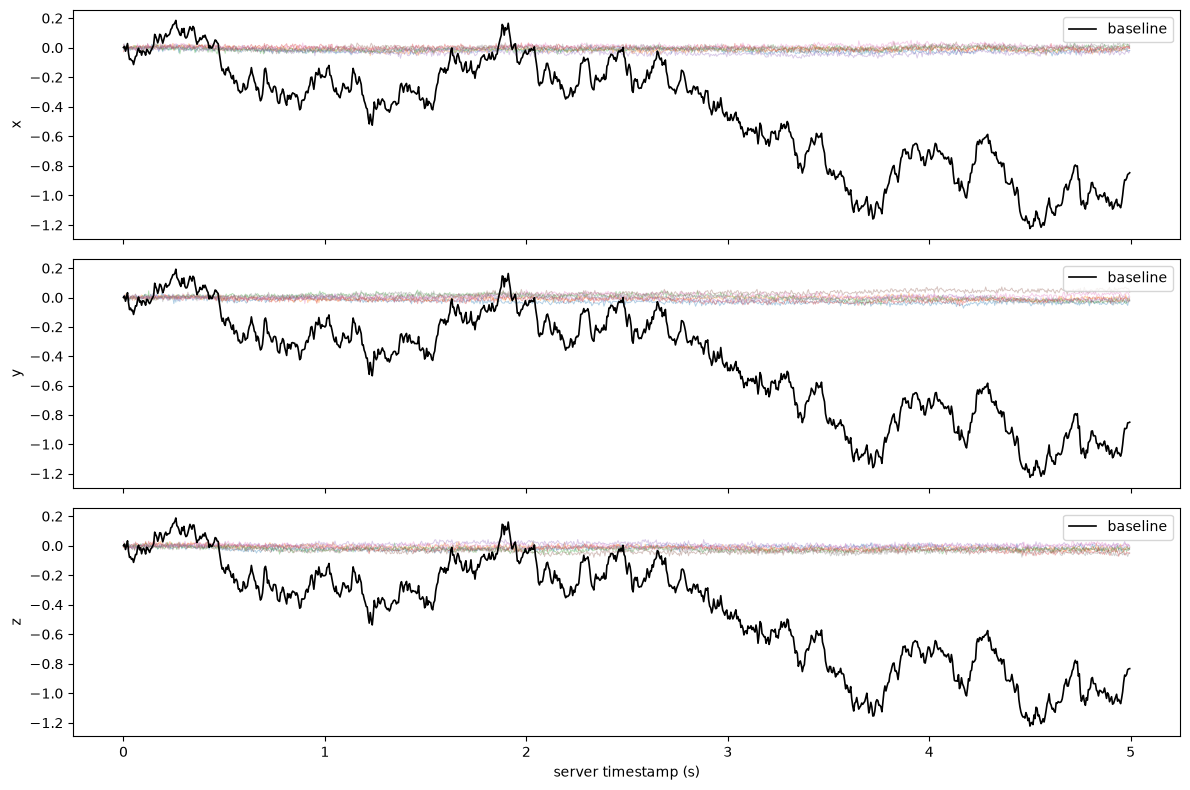

In [4]:
def read_port(port):
    samples = live_clients[port].read_samples(NUMBER_OF_LIVE_SAMPLES)
    return pd.DataFrame(samples)
try:
    with ThreadPoolExecutor(max_workers=9) as pool:
        raw_by_port = dict(zip(live_clients, pool.map(read_port, live_clients)))
finally:
    for client in live_clients.values():
        client.close()
raw_live = {}
for port, frame in raw_by_port.items():
    label = "baseline" if port == BASELINE_PORT else f"gyro{port - 5000}"
    raw_live[label] = frame.rename(columns={"x": f"{label}_x", "y": f"{label}_y", "z": f"{label}_z"})
print({name: len(frame) for name, frame in raw_live.items()})
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for axis, ax in zip(("x", "y", "z"), axes):
    for i in GYRO_IDS:
        ax.plot(raw_live[f"gyro{i}"].timestamp, raw_live[f"gyro{i}"][f"gyro{i}_{axis}"], alpha=.35, lw=.7)
    ax.plot(raw_live["baseline"].timestamp, raw_live["baseline"][f"baseline_{axis}"], color="black", lw=1.2, label="baseline")
    ax.set_ylabel(axis)
    ax.legend(loc="upper right")
axes[-1].set_xlabel("server timestamp (s)")
fig.tight_layout(); fig.savefig(RESULTS_DIR / "live_raw_streams.png", dpi=140); plt.show(); plt.close(fig)


# Validation

Validation is performed on received samples before any alignment or fusion.

In [5]:
validation_rows = []
for name, frame in raw_live.items():
    ts = frame["timestamp"].to_numpy()
    validation_rows.append({"stream": name, "rows": len(frame), "finite": bool(np.isfinite(frame.select_dtypes("number")).all().all()),
                            "strictly_increasing": bool(np.all(np.diff(ts) > 0)), "duplicate_timestamps": int(pd.Series(ts).duplicated().sum()),
                            "columns": len(frame.columns)})
validation = pd.DataFrame(validation_rows)
print(validation)
if not bool(validation["finite"].all()) or not bool((validation["rows"] == NUMBER_OF_LIVE_SAMPLES).all()):
    raise RuntimeError("Live validation failed: non-finite or incomplete stream")


     stream  rows  finite  strictly_increasing  duplicate_timestamps  columns
0     gyro1  1000    True                 True                     0        4
1     gyro2  1000    True                 True                     0        4
2     gyro3  1000    True                 True                     0        4
3     gyro4  1000    True                 True                     0        4
4     gyro5  1000    True                 True                     0        4
5     gyro6  1000    True                 True                     0        4
6     gyro7  1000    True                 True                     0        4
7     gyro8  1000    True                 True                     0        4
8  baseline  1000    True                 True                     0        4


# Timestamp alignment

Streams are aligned by nearest delivered timestamps within half a sample period. No interpolation or offline data is used.

In [6]:
def align_live_streams(streams, tolerance=DT / 2.0):
    prepared = {}
    for name, frame in streams.items():
        keep = ["timestamp"] + [f"{name}_{axis}" for axis in ("x", "y", "z")]
        prepared[name] = (frame[keep].drop_duplicates("timestamp").sort_values("timestamp").reset_index(drop=True))
    base = prepared["gyro1"]
    aligned = base.rename(columns={f"gyro1_{a}": f"gyro1_{a}" for a in ("x", "y", "z")})
    for name in [f"gyro{i}" for i in GYRO_IDS[1:]] + ["baseline"]:
        aligned = pd.merge_asof(aligned.sort_values("timestamp"), prepared[name].sort_values("timestamp"),
                                on="timestamp", direction="nearest", tolerance=tolerance)
    aligned = aligned.dropna().reset_index(drop=True)
    if aligned.empty:
        raise RuntimeError("Timestamp alignment produced no common live samples")
    return aligned
aligned_live = align_live_streams(raw_live)
alignment_summary = pd.DataFrame([{"aligned_rows": len(aligned_live), "start_timestamp": aligned_live.timestamp.iloc[0],
                                  "end_timestamp": aligned_live.timestamp.iloc[-1], "duration_seconds": aligned_live.timestamp.iloc[-1] - aligned_live.timestamp.iloc[0]}])
alignment_summary.to_csv(RESULTS_DIR / "live_alignment_summary.csv", index=False)
print(alignment_summary)


   aligned_rows  start_timestamp  end_timestamp  duration_seconds
0          1000              0.0          4.995             4.995


# Correlation

Correlation matrices are computed from the aligned live batch and visualized as heatmaps.

C:\Users\shara\AppData\Local\Temp\ipykernel_24496\4148337107.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); fig.savefig(RESULTS_DIR / "live_correlation_heatmaps.png", dpi=140); plt.show(); plt.close(fig)


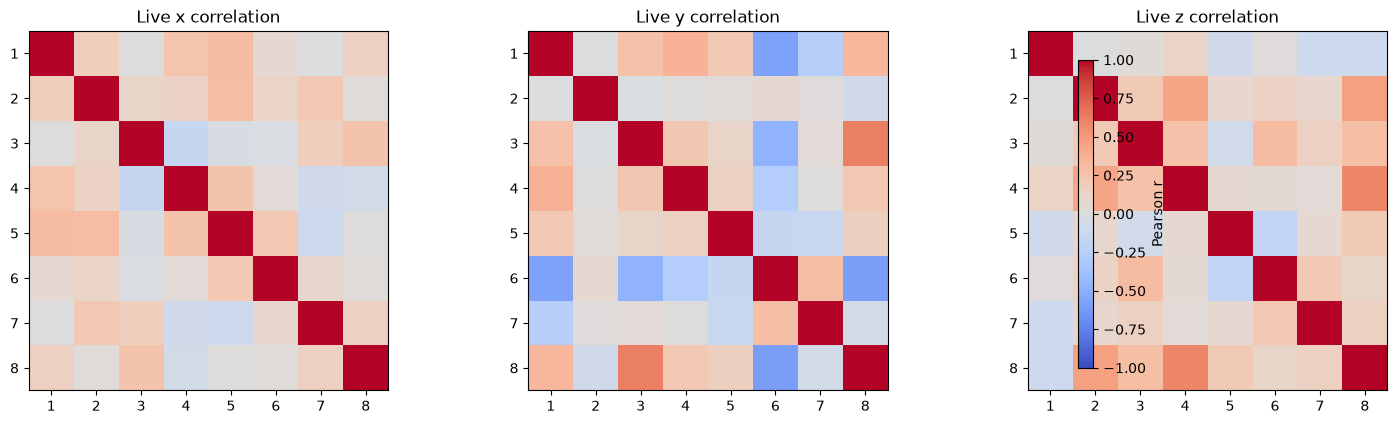

In [7]:
correlation_matrices = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, ax in zip(("x", "y", "z"), axes):
    cols = [f"gyro{i}_{axis}" for i in GYRO_IDS]
    matrix = aligned_live[cols].corr()
    correlation_matrices[axis] = matrix
    matrix.to_csv(RESULTS_DIR / f"live_correlation_matrix_{axis}.csv")
    image = ax.imshow(matrix.to_numpy(), vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_title(f"Live {axis} correlation")
    ax.set_xticks(range(8), GYRO_IDS); ax.set_yticks(range(8), GYRO_IDS)
fig.colorbar(image, ax=axes.ravel().tolist(), label="Pearson r")
fig.tight_layout(); fig.savefig(RESULTS_DIR / "live_correlation_heatmaps.png", dpi=140); plt.show(); plt.close(fig)


# Basic fusion

Arithmetic mean fusion is a transparent baseline, computed only from aligned live gyro values.

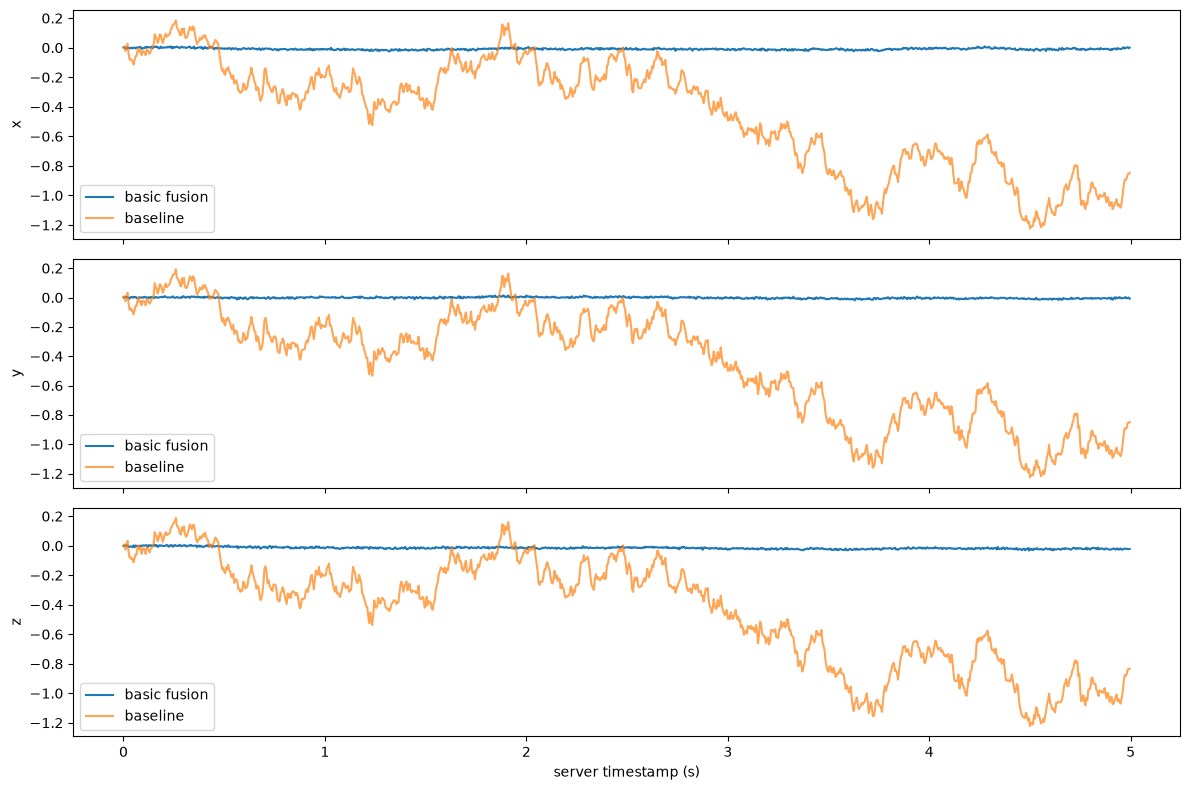

In [8]:
basic_fusion = pd.DataFrame({"timestamp": aligned_live.timestamp})
for axis in ("x", "y", "z"):
    basic_fusion[f"fused_{axis}"] = aligned_live[[f"gyro{i}_{axis}" for i in GYRO_IDS]].mean(axis=1)
basic_fusion.to_csv(RESULTS_DIR / "live_basic_fusion.csv", index=False)
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for axis, ax in zip(("x", "y", "z"), axes):
    ax.plot(aligned_live.timestamp, basic_fusion[f"fused_{axis}"], label="basic fusion")
    ax.plot(aligned_live.timestamp, aligned_live[f"baseline_{axis}"], label="baseline", alpha=.7)
    ax.set_ylabel(axis); ax.legend()
axes[-1].set_xlabel("server timestamp (s)"); fig.tight_layout(); fig.savefig(RESULTS_DIR / "live_basic_fusion.png", dpi=140); plt.show(); plt.close(fig)


# IMM config

The IMM is a scalar linear-Gaussian random-walk bank. Process-noise variances are deliberately distinct.

In [9]:
IMM_PROCESS_NOISES = (1e-5, 3e-4, 3e-3)
IMM_MEASUREMENT_NOISE = 1e-3
IMM_TRANSITION = np.array([[.97, .02, .01], [.02, .96, .02], [.01, .02, .97]])
print({"process_noises": IMM_PROCESS_NOISES, "measurement_noise": IMM_MEASUREMENT_NOISE,
       "transition_matrix": IMM_TRANSITION.tolist()})


{'process_noises': (1e-05, 0.0003, 0.003), 'measurement_noise': 0.001, 'transition_matrix': [[0.97, 0.02, 0.01], [0.02, 0.96, 0.02], [0.01, 0.02, 0.97]]}


# IMM independent test

This smoke test uses the first live aligned gyro axis, not an offline substitute, and verifies probabilities and finite estimates.

In [10]:
imm_test_values = aligned_live["gyro1_x"].to_numpy()[:min(50, len(aligned_live))]
imm_test = LinearGaussian1DIMM(IMM_PROCESS_NOISES, IMM_MEASUREMENT_NOISE, IMM_TRANSITION)
imm_test_results = imm_test.filter(imm_test_values, dt=DT)
if imm_test_results.empty or not np.isfinite(imm_test_results["estimate"]).all():
    raise RuntimeError("IMM independent test failed")
prob_cols = [c for c in imm_test_results if c.startswith("model_probability_")]
if not np.allclose(imm_test_results[prob_cols].sum(axis=1), 1.0, atol=1e-8):
    raise RuntimeError("IMM model probabilities are not normalized")
print(imm_test_results.tail(1))


    index  estimate  covariance  model_probability_0  model_probability_1  \
49     49 -0.004766    0.000051             0.426179             0.357967   

    model_probability_2  
49             0.215853  


# Association config

PMA is a single-target, JPDA-like association: gating and likelihood normalization include an explicit missed-detection hypothesis.

In [11]:
ASSOCIATION_GATE_THRESHOLD = 9.0
ASSOCIATION_DETECTION_PROBABILITY = .95
ASSOCIATION_MEASUREMENT_NOISE = .01
print({"gate_threshold_squared_mahalanobis": ASSOCIATION_GATE_THRESHOLD,
       "detection_probability": ASSOCIATION_DETECTION_PROBABILITY,
       "measurement_noise": ASSOCIATION_MEASUREMENT_NOISE})


{'gate_threshold_squared_mahalanobis': 9.0, 'detection_probability': 0.95, 'measurement_noise': 0.01}


# IMM+association pipeline

For every aligned live timestamp, PMA gates the eight gyro measurements and feeds its weighted measurement into an IMM.

In [12]:
pipeline = {"timestamp": aligned_live.timestamp.to_numpy()}
for axis in ("x", "y", "z"):
    imm = LinearGaussian1DIMM(IMM_PROCESS_NOISES, IMM_MEASUREMENT_NOISE, IMM_TRANSITION)
    estimates, covariances, fused_measurements, missed, gated_count = [], [], [], [], []
    previous = float(aligned_live[f"gyro1_{axis}"].iloc[0])
    previous_covariance = 1.0
    for values in aligned_live[[f"gyro{i}_{axis}" for i in GYRO_IDS]].to_numpy():
        association = pma_update(values, previous, previous_covariance, ASSOCIATION_MEASUREMENT_NOISE,
                                  gate_threshold=ASSOCIATION_GATE_THRESHOLD,
                                  detection_probability=ASSOCIATION_DETECTION_PROBABILITY)
        measurement = association.fused_measurement
        if measurement is None:
            measurement = previous
        result = imm.step(measurement, dt=DT)
        previous, previous_covariance = result.estimate, result.covariance
        estimates.append(result.estimate); covariances.append(result.covariance)
        fused_measurements.append(association.fused_measurement if association.fused_measurement is not None else np.nan)
        missed.append(association.missed_detection_probability); gated_count.append(int(association.gated.sum()))
    pipeline[f"imm_{axis}"] = np.asarray(estimates)
    pipeline[f"imm_{axis}_covariance"] = np.asarray(covariances)
    pipeline[f"association_{axis}"] = np.asarray(fused_measurements)
    pipeline[f"association_{axis}_missed_probability"] = np.asarray(missed)
    pipeline[f"association_{axis}_gated_count"] = np.asarray(gated_count)
processed_live = pd.DataFrame(pipeline)
processed_live.to_csv(RESULTS_DIR / "live_imm_association.csv", index=False)
print(processed_live.head())


   timestamp     imm_x  imm_x_covariance  association_x  \
0      0.000  0.001119          0.000999       0.001120   
1      0.005  0.003137          0.000501       0.005146   
2      0.010  0.000458          0.000336      -0.004830   
3      0.015 -0.001672          0.000255      -0.007906   
4      0.020 -0.000698          0.000206       0.003042   

   association_x_missed_probability  association_x_gated_count     imm_y  \
0                          0.117087                          8  0.001184   
1                          0.013730                          8  0.000164   
2                          0.013429                          8  0.001259   
3                          0.013306                          8  0.001949   
4                          0.013231                          8  0.002452   

   imm_y_covariance  association_y  association_y_missed_probability  \
0          0.000999       0.001185                          0.117072   
1          0.000501      -0.000851          

# EKF on processed estimate

The existing basic EKF is applied to the IMM+PMA estimate, not to offline or unprocessed data.

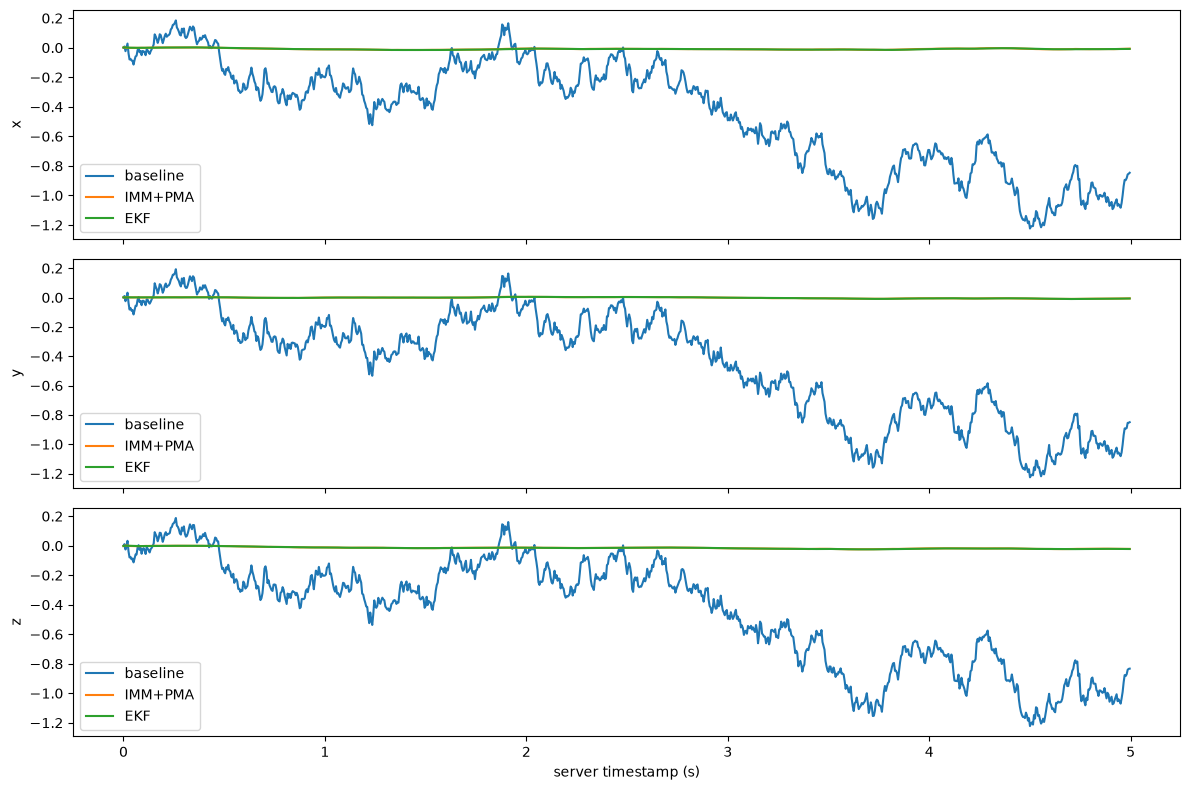

In [13]:
ekf_input = pd.DataFrame({"timestamp": processed_live.timestamp})
for axis in ("x", "y", "z"):
    ekf_input[f"fused_{axis}"] = processed_live[f"imm_{axis}"]
ekf_processed = run_basic_ekf(ekf_input, dt=DT)
ekf_processed.to_csv(RESULTS_DIR / "live_ekf_processed.csv", index=False)
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for axis, ax in zip(("x", "y", "z"), axes):
    ax.plot(aligned_live.timestamp, aligned_live[f"baseline_{axis}"], label="baseline")
    ax.plot(processed_live.timestamp, processed_live[f"imm_{axis}"], label="IMM+PMA")
    ax.plot(ekf_processed.timestamp, ekf_processed[f"ekf_{axis}"], label="EKF")
    ax.set_ylabel(axis); ax.legend()
axes[-1].set_xlabel("server timestamp (s)"); fig.tight_layout(); fig.savefig(RESULTS_DIR / "live_processed_estimates.png", dpi=140); plt.show(); plt.close(fig)


# Baseline validation

The baseline is used as the received live reference only after alignment; errors and error plots are actual measurements.

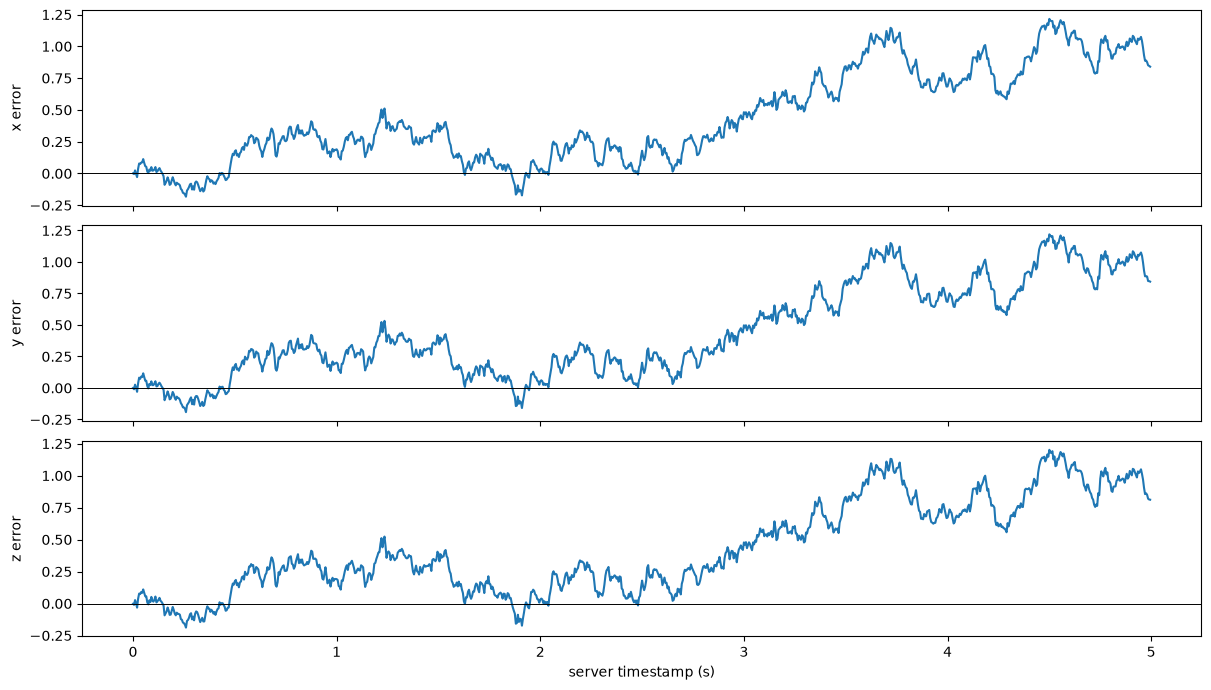

  axis  rows  finite  mean_error      rmse
0    x  1000    True    0.434331  0.568285
1    y  1000    True    0.444507  0.573688
2    z  1000    True    0.429791  0.559335


In [14]:
baseline_validation = []
for axis in ("x", "y", "z"):
    error = processed_live[f"imm_{axis}"].to_numpy() - aligned_live[f"baseline_{axis}"].to_numpy()
    baseline_validation.append({"axis": axis, "rows": len(error), "finite": bool(np.isfinite(error).all()),
                                "mean_error": float(error.mean()), "rmse": float(np.sqrt(np.mean(error ** 2)))})
baseline_validation = pd.DataFrame(baseline_validation)
baseline_validation.to_csv(RESULTS_DIR / "live_baseline_validation.csv", index=False)
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for axis, ax in zip(("x", "y", "z"), axes):
    error = processed_live[f"imm_{axis}"] - aligned_live[f"baseline_{axis}"]
    ax.plot(aligned_live.timestamp, error); ax.axhline(0, color="black", lw=.7); ax.set_ylabel(f"{axis} error")
axes[-1].set_xlabel("server timestamp (s)"); fig.tight_layout(); fig.savefig(RESULTS_DIR / "live_processed_errors.png", dpi=140); plt.show(); plt.close(fig)
print(baseline_validation)


# Allan variance with selectable ALLAN_SOURCE

Allan deviation is calculated from a live aligned series. The selected source is explicit and invalid selections fail.

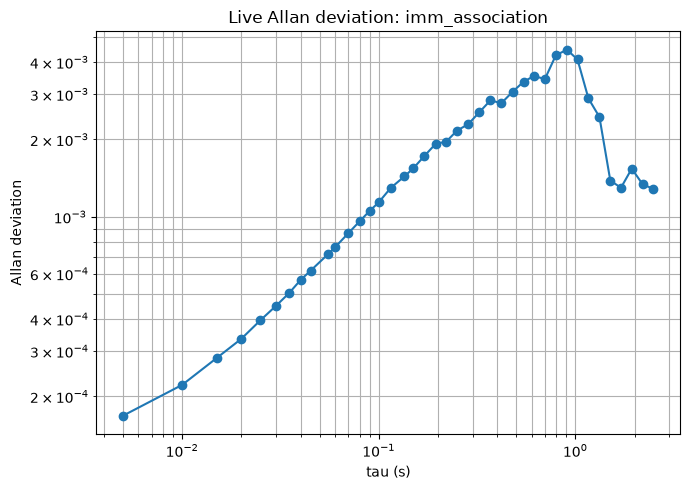

In [15]:
allan_sources = {
    "live_gyro1": aligned_live["gyro1_x"].to_numpy(),
    "basic_fusion": basic_fusion["fused_x"].to_numpy(),
    "imm_association": processed_live["imm_x"].to_numpy(),
    "ekf": ekf_processed["ekf_x"].to_numpy(),
}
if ALLAN_SOURCE not in allan_sources:
    raise ValueError(f"Unknown ALLAN_SOURCE={ALLAN_SOURCE}; choose {sorted(allan_sources)}")
allan_values = allan_sources[ALLAN_SOURCE]
allan_tau, allan_adev = allan_deviation(allan_values, SAMPLE_RATE)
finite_allan = np.isfinite(allan_tau) & np.isfinite(allan_adev) & (allan_adev > 0)
allan_tau, allan_adev = allan_tau[finite_allan], allan_adev[finite_allan]
pd.DataFrame({"tau_seconds": allan_tau, "allan_deviation": allan_adev}).to_csv(RESULTS_DIR / "live_allan_deviation.csv", index=False)
fig, ax = plt.subplots(figsize=(7, 5)); ax.loglog(allan_tau, allan_adev, "o-"); ax.set_xlabel("tau (s)"); ax.set_ylabel("Allan deviation"); ax.set_title(f"Live Allan deviation: {ALLAN_SOURCE}"); ax.grid(True, which="both"); fig.tight_layout(); fig.savefig(RESULTS_DIR / "live_allan_deviation.png", dpi=140); plt.show(); plt.close(fig)


# ARW extraction with fit and honest insufficient-data handling

ARW is estimated only when a minimum short-tau region exists and has a plausible negative half slope. Otherwise the result is explicitly `INSUFFICIENT_DATA`.

In [16]:
def fit_noise_region(tau, adev, slope_target, low_tau, high_tau, minimum_points=5, slope_tolerance=.35):
    mask = (tau >= low_tau) & (tau <= high_tau) & np.isfinite(adev) & (adev > 0)
    if int(mask.sum()) < minimum_points:
        return {"status": "INSUFFICIENT_DATA", "points": int(mask.sum()), "slope": np.nan, "coefficient": np.nan}
    x, y = np.log10(tau[mask]), np.log10(adev[mask])
    slope, intercept = np.polyfit(x, y, 1)
    fitted_coefficient = float(10 ** intercept)
    status = "PASS" if abs(slope - slope_target) <= slope_tolerance else "SLOPE_NOT_CONCLUSIVE"
    # Do not present a coefficient as ARW/RRW unless the target slope is supported.
    coefficient = fitted_coefficient if status == "PASS" else np.nan
    return {"status": status, "points": int(mask.sum()), "slope": float(slope), "coefficient": coefficient}

record_length = len(allan_values) * DT
arw = fit_noise_region(allan_tau, allan_adev, -.5, 2 * DT, max(2 * DT, .2 * record_length)) if len(allan_tau) else {"status":"INSUFFICIENT_DATA","points":0,"slope":np.nan,"coefficient":np.nan}
print("ARW:", arw)


ARW: {'status': 'SLOPE_NOT_CONCLUSIVE', 'points': 31, 'slope': 0.6840460807676632, 'coefficient': nan}


# RRW extraction with honest insufficient-data handling

RRW uses a long-tau region and is not reported when the live record does not contain enough independent clusters.

In [17]:
rrw = fit_noise_region(allan_tau, allan_adev, .5, max(2 * DT, .2 * record_length), record_length / 2, minimum_points=5) if len(allan_tau) else {"status":"INSUFFICIENT_DATA","points":0,"slope":np.nan,"coefficient":np.nan}
print("RRW:", rrw)


RRW: {'status': 'SLOPE_NOT_CONCLUSIVE', 'points': 8, 'slope': -1.25954179987507, 'coefficient': nan}


# Accuracy metrics

MAE and RMSE compare each processed live estimate and basic fusion with the aligned live baseline.

In [18]:
accuracy_rows = []
for name, frame, prefix in [("basic_fusion", basic_fusion, "fused"), ("imm_association", processed_live, "imm"), ("ekf", ekf_processed, "ekf")]:
    for axis in ("x", "y", "z"):
        error = frame[f"{prefix}_{axis}"].to_numpy() - aligned_live[f"baseline_{axis}"].to_numpy()
        accuracy_rows.append({"method": name, "axis": axis, "mae": float(np.mean(np.abs(error))),
                              "rmse": float(np.sqrt(np.mean(error ** 2))), "max_abs_error": float(np.max(np.abs(error)))})
accuracy_metrics = pd.DataFrame(accuracy_rows)
accuracy_metrics.to_csv(RESULTS_DIR / "live_accuracy_metrics.csv", index=False)
print(accuracy_metrics)


            method axis       mae      rmse  max_abs_error
0     basic_fusion    x  0.447180  0.567925       1.214705
1     basic_fusion    y  0.456748  0.573624       1.215810
2     basic_fusion    z  0.442262  0.558794       1.203257
3  imm_association    x  0.447513  0.568285       1.215886
4  imm_association    y  0.456859  0.573688       1.219188
5  imm_association    z  0.442823  0.559335       1.201576
6              ekf    x  0.447340  0.568127       1.217048
7              ekf    y  0.456879  0.573669       1.219581
8              ekf    z  0.442519  0.558987       1.201651


# Latency measurements using perf_counter

Latency is measured around actual per-sample processing calls with `perf_counter`; it is not inferred from sample count.

In [19]:
latency_rows = []
for axis in ("x", "y", "z"):
    values = aligned_live[[f"gyro{i}_{axis}" for i in GYRO_IDS]].to_numpy()
    imm = LinearGaussian1DIMM(IMM_PROCESS_NOISES, IMM_MEASUREMENT_NOISE, IMM_TRANSITION)
    previous, previous_cov = float(values[0, 0]), 1.0
    for row in values:
        start = time.perf_counter()
        assoc = pma_update(row, previous, previous_cov, ASSOCIATION_MEASUREMENT_NOISE, gate_threshold=ASSOCIATION_GATE_THRESHOLD, detection_probability=ASSOCIATION_DETECTION_PROBABILITY)
        value = previous if assoc.fused_measurement is None else assoc.fused_measurement
        result = imm.step(value, dt=DT)
        elapsed = time.perf_counter() - start
        previous, previous_cov = result.estimate, result.covariance
        latency_rows.append({"axis": axis, "latency_seconds": elapsed, "latency_microseconds": elapsed * 1e6})
latency_metrics = pd.DataFrame(latency_rows)
latency_summary = latency_metrics.groupby("axis")["latency_microseconds"].agg(["mean", "median", "max"]).reset_index()
latency_metrics.to_csv(RESULTS_DIR / "live_latency_samples.csv", index=False)
latency_summary.to_csv(RESULTS_DIR / "live_latency_summary.csv", index=False)
print(latency_summary)


  axis     mean     median         max
0    x  73.0080  69.999995  236.500011
1    y  71.5995  69.599992  180.999996
2    z  72.0002  69.500005  290.299999


# Accuracy-vs-latency

This plot joins measured processing latency with the corresponding live-baseline RMSE.

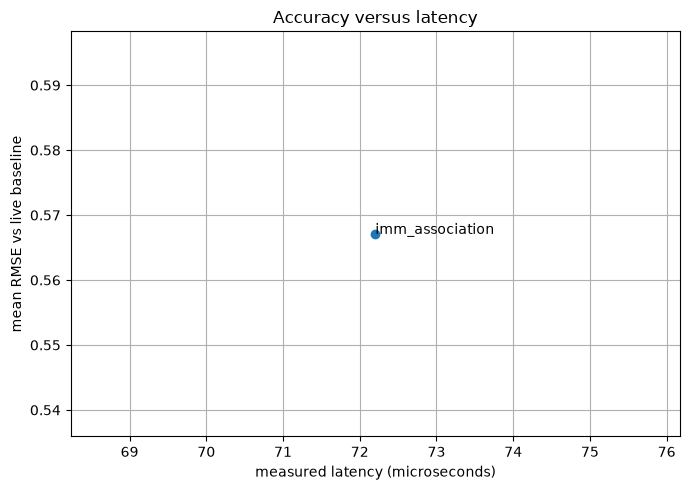

            method  mean_rmse  latency_microseconds
0     basic_fusion   0.566781                   NaN
1              ekf   0.566928                   NaN
2  imm_association   0.567103             72.202567


In [20]:
method_latency = pd.DataFrame([
    {"method": "basic_fusion", "latency_microseconds": np.nan},
    {"method": "imm_association", "latency_microseconds": latency_summary["mean"].mean()},
    {"method": "ekf", "latency_microseconds": np.nan},
])
method_accuracy = accuracy_metrics.groupby("method", as_index=False)["rmse"].mean().rename(columns={"rmse":"mean_rmse"})
accuracy_latency = method_accuracy.merge(method_latency, on="method", how="left")
accuracy_latency.to_csv(RESULTS_DIR / "live_accuracy_vs_latency.csv", index=False)
fig, ax = plt.subplots(figsize=(7, 5)); plotted = accuracy_latency.dropna(subset=["latency_microseconds"])
ax.scatter(plotted.latency_microseconds, plotted.mean_rmse)
for _, row in plotted.iterrows(): ax.annotate(row.method, (row.latency_microseconds, row.mean_rmse))
ax.set_xlabel("measured latency (microseconds)"); ax.set_ylabel("mean RMSE vs live baseline"); ax.set_title("Accuracy versus latency"); ax.grid(True); fig.tight_layout(); fig.savefig(RESULTS_DIR / "live_accuracy_vs_latency.png", dpi=140); plt.show(); plt.close(fig)
print(accuracy_latency)


# Final comparison

The final table compares the live methods and records the analysis statuses without fabricating unavailable noise coefficients.

In [21]:
final_comparison = accuracy_latency.copy()
final_comparison["arw_status"] = arw["status"]
final_comparison["rrw_status"] = rrw["status"]
final_comparison.to_csv(RESULTS_DIR / "live_final_comparison.csv", index=False)
print(final_comparison)


            method  mean_rmse  latency_microseconds            arw_status  \
0     basic_fusion   0.566781                   NaN  SLOPE_NOT_CONCLUSIVE   
1              ekf   0.566928                   NaN  SLOPE_NOT_CONCLUSIVE   
2  imm_association   0.567103             72.202567  SLOPE_NOT_CONCLUSIVE   

             rrw_status  
0  SLOPE_NOT_CONCLUSIVE  
1  SLOPE_NOT_CONCLUSIVE  
2  SLOPE_NOT_CONCLUSIVE  


# Final summary

This summary is generated from executed live variables and lists explicit limitations.

In [22]:
summary_lines = [
    "LIVE 9-PORT RESEARCH PIPELINE SUMMARY",
    f"ports: PASS ({len(live_clients)} connected)",
    f"received samples per stream: {NUMBER_OF_LIVE_SAMPLES}",
    f"aligned live rows: {len(aligned_live)}",
    f"ALLAN_SOURCE: {ALLAN_SOURCE}",
    f"ARW: {arw}",
    f"RRW: {rrw}",
    "IMM: PASS (linear Gaussian scalar random-walk models with explicit mixing, likelihoods, and model probabilities)",
    "Association: PASS (single-target PMA; not full classical JPDA and has no multi-target joint-event or clutter model)",
    "Offline data: reference-only; no offline fallback was used.",
    "Generated artifacts are under data/results.",
]
(RESULTS_DIR / "live_final_summary.txt").write_text("\n".join(summary_lines), encoding="utf-8")
print("\n".join(summary_lines))


LIVE 9-PORT RESEARCH PIPELINE SUMMARY
ports: PASS (9 connected)
received samples per stream: 1000
aligned live rows: 1000
ALLAN_SOURCE: imm_association
ARW: {'status': 'SLOPE_NOT_CONCLUSIVE', 'points': 31, 'slope': 0.6840460807676632, 'coefficient': nan}
RRW: {'status': 'SLOPE_NOT_CONCLUSIVE', 'points': 8, 'slope': -1.25954179987507, 'coefficient': nan}
IMM: PASS (linear Gaussian scalar random-walk models with explicit mixing, likelihoods, and model probabilities)
Association: PASS (single-target PMA; not full classical JPDA and has no multi-target joint-event or clutter model)
Offline data: reference-only; no offline fallback was used.
Generated artifacts are under data/results.
